<a href="https://colab.research.google.com/github/rezaDamansabz/Boston_Housing_Analysis_statistics_DataScience/blob/main/Housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#“Boston Housing Data Analysis: Insights on Prices, Location, and Environmental Factors

##Project Scenario:
You are a Data Scientist with a housing agency in Boston MA, you have been given access to a previous dataset on housing prices derived from the U.S. Census Service to present insights to higher management. Based on your experience in Statistics, what information can you provide them to help with making an informed decision? Upper management will like to get some insight into the following.

- Is there a significant difference in the median value of houses bounded by the Charles river or not?

- Is there a difference in median values of houses of each proportion of owner-occupied units built before 1940?

- Can we conclude that there is no relationship between Nitric oxide concentrations and the proportion of non-retail business acres per town?

- What is the impact of an additional weighted distance to the five Boston employment centres on the median value of owner-occupied homes?

Using the appropriate graphs and charts, generate basic statistics and visualizations that you think will be useful for the upper management to give them important insight given the question they are asking, in your graphs, include an explanation of each statistic.



##Project Tasks:

**Task 1**: Familiarize yourself with the dataset

**Task 2**: Generate basic statistics and visualizations for upper management.

**Task 3**: Use the appropriate tests to answer the questions provided.

## Dataset Variables
The following describes the dataset variables:

·      CRIM - per capita crime rate by town

·      ZN - proportion of residential land zoned for lots over 25,000 sq.ft.

·      INDUS - proportion of non-retail business acres per town.

·      CHAS - Charles River dummy variable (1 if tract bounds river; 0 otherwise)

·      NOX - nitric oxides concentration (parts per 10 million)

·      RM - average number of rooms per dwelling

·      AGE - proportion of owner-occupied units built prior to 1940

·      DIS - weighted distances to five Boston employment centres

·      RAD - index of accessibility to radial highways

·      TAX - full-value property-tax rate per $10,000

·      PTRATIO - pupil-teacher ratio by town

·      LSTAT - % lower status of the population

·      MEDV - Median value of owner-occupied homes in $1000's

###Importing libraries

In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

###Load the Dataset

In [43]:
#Load the dataset:
boston_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
boston_df=pd.read_csv(boston_url)

#Task 1:
Familiarize yourself with the dataset

In [44]:
#Check data info, and have a glance on the data
boston_df.info()
boston_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.5 KB


,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [ ]:
#Check for missing values
boston_df.isnull().sum()

,0
Unnamed: 0,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0


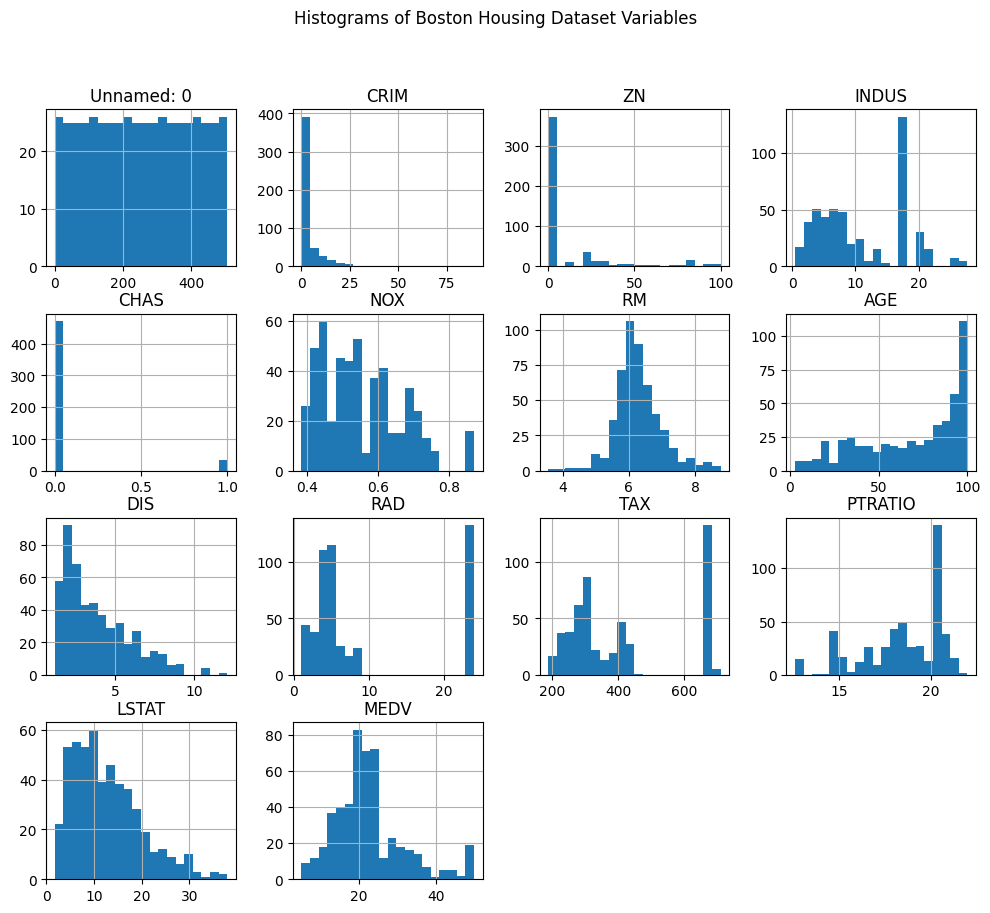

In [ ]:
#Examine the distribution of variables
boston_df.hist(figsize=(12,10), bins=20)
plt.suptitle("Histograms of Boston Housing Dataset Variables")
plt.show()


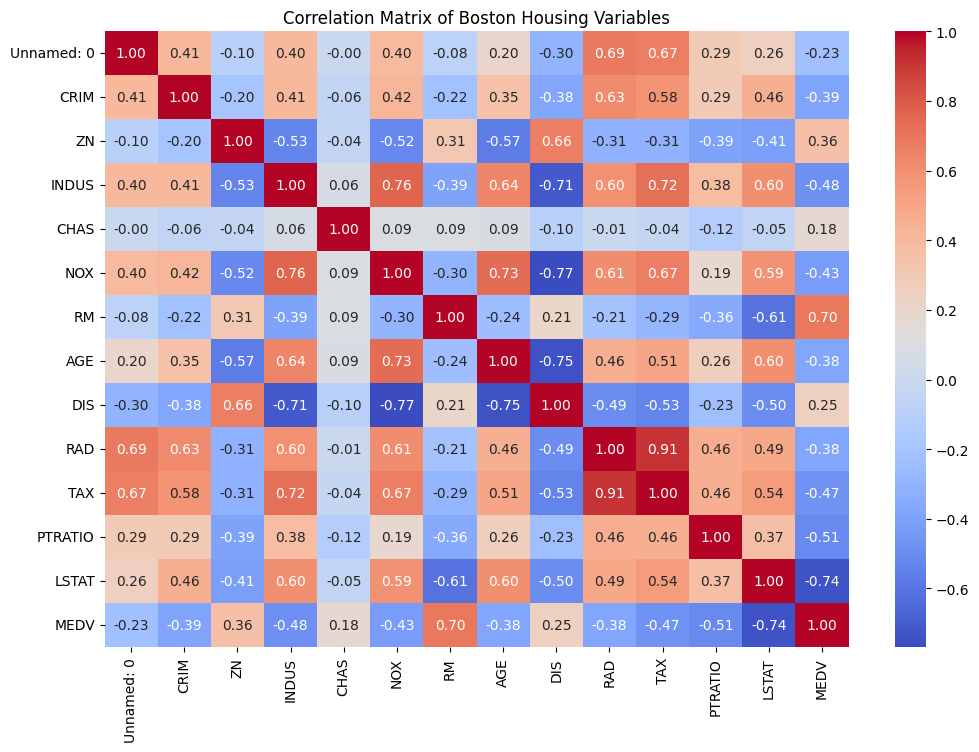

In [ ]:
#Check correlations
plt.figure(figsize=(12,8))
sns.heatmap(boston_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Boston Housing Variables")
plt.show()

In [ ]:
# 8. Correlation of MEDV with other variables (sorted)
print("\n----- MEDV Correlation with Other Variables -----")
print(boston_df.corr()['MEDV'].sort_values(ascending=False))


----- MEDV Correlation with Other Variables -----
MEDV          1.000000
RM            0.695360
ZN            0.360445
DIS           0.249929
CHAS          0.175260
Unnamed: 0   -0.226604
AGE          -0.376955
RAD          -0.381626
CRIM         -0.388305
NOX          -0.427321
TAX          -0.468536
INDUS        -0.483725
PTRATIO      -0.507787
LSTAT        -0.737663
Name: MEDV, dtype: float64


#Task 2:
Generate basic statistics and visualizations for upper management.

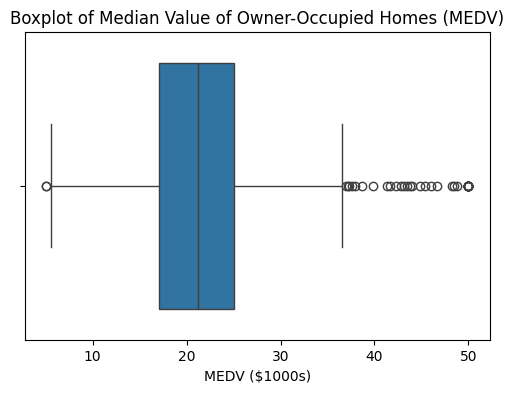

Observation: The boxplot shows the median, quartiles, and possible outliers in housing prices. Outliers indicate some extremely high-valued homes that may influence statistical tests.


In [ ]:
#Boxplot for MEDV
plt.figure(figsize=(6,4))
sns.boxplot(x=boston_df['MEDV'])
plt.title("Boxplot of Median Value of Owner-Occupied Homes (MEDV)")
plt.xlabel("MEDV ($1000s)")
plt.show()

print("Observation: The boxplot shows the median, quartiles, and possible outliers in housing prices. "
      "Outliers indicate some extremely high-valued homes that may influence statistical tests.")


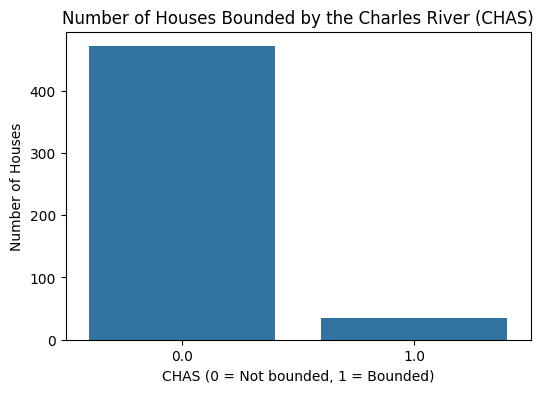

Observation: This bar plot shows how many properties are located next to the Charles River vs. not. This helps assess whether sample sizes are balanced for t-test comparisons.


In [ ]:
# 2. Bar plot for Charles River variable (CHAS)
chas_counts = boston_df['CHAS'].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=chas_counts.index, y=chas_counts.values)
plt.title("Number of Houses Bounded by the Charles River (CHAS)")
plt.xlabel("CHAS (0 = Not bounded, 1 = Bounded)")
plt.ylabel("Number of Houses")
plt.show()

print("Observation: This bar plot shows how many properties are located next to the Charles River vs. not. "
      "This helps assess whether sample sizes are balanced for t-test comparisons.")


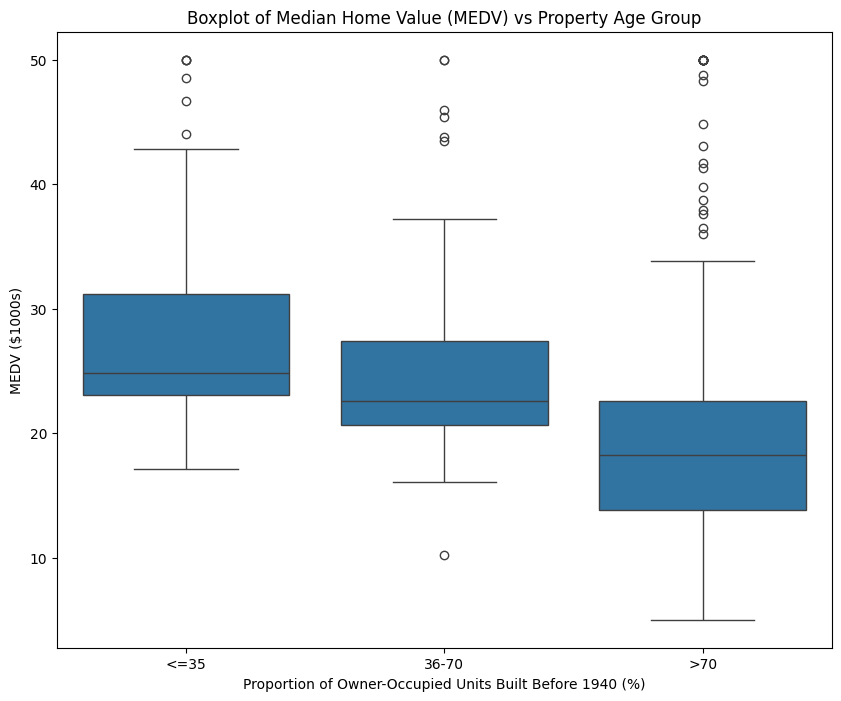

Observation: The boxplot shows how median home values vary across age groups of houses. Older properties may show different price distributions compared to newer ones.


In [ ]:
# 3. Boxplot of MEDV vs AGE (discretized)
# Create AGE groups: <=35, 36-70, >70
age_bins = [0, 35, 70, 100]
age_labels = ['<=35', '36-70', '>70']
boston_df['AGE_group'] = pd.cut(boston_df['AGE'], bins=age_bins, labels=age_labels)

plt.figure(figsize=(10,8))
sns.boxplot(x='AGE_group', y='MEDV', data=boston_df)
plt.title("Boxplot of Median Home Value (MEDV) vs Property Age Group")
plt.xlabel("Proportion of Owner-Occupied Units Built Before 1940 (%)")
plt.ylabel("MEDV ($1000s)")
plt.show()

print("Observation: The boxplot shows how median home values vary across age groups of houses. "
      "Older properties may show different price distributions compared to newer ones.")


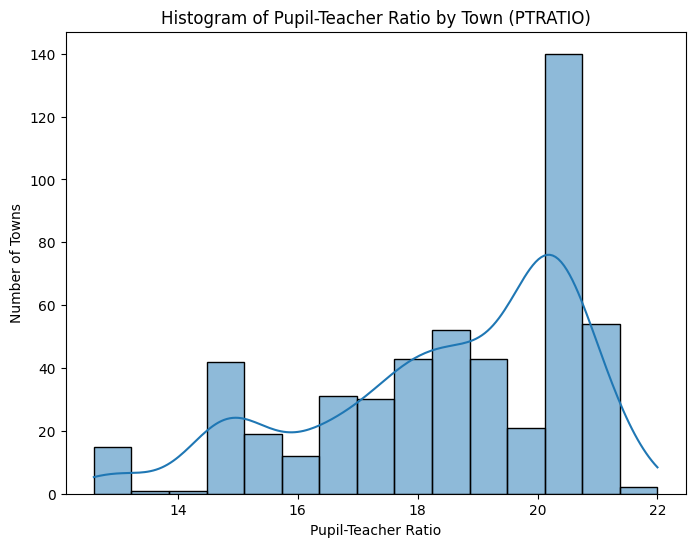

Observation: The histogram displays the distribution of pupil-teacher ratios. Most towns cluster around typical PTRATIO values, helping assess educational environment impacts.


In [ ]:
# 4. Histogram for pupil-teacher ratio (PTRATIO)
plt.figure(figsize=(8,6))
sns.histplot(boston_df['PTRATIO'], bins=15, kde=True)
plt.title("Histogram of Pupil-Teacher Ratio by Town (PTRATIO)")
plt.xlabel("Pupil-Teacher Ratio")
plt.ylabel("Number of Towns")
plt.show()

print("Observation: The histogram displays the distribution of pupil-teacher ratios. "
      "Most towns cluster around typical PTRATIO values, helping assess educational environment impacts.")


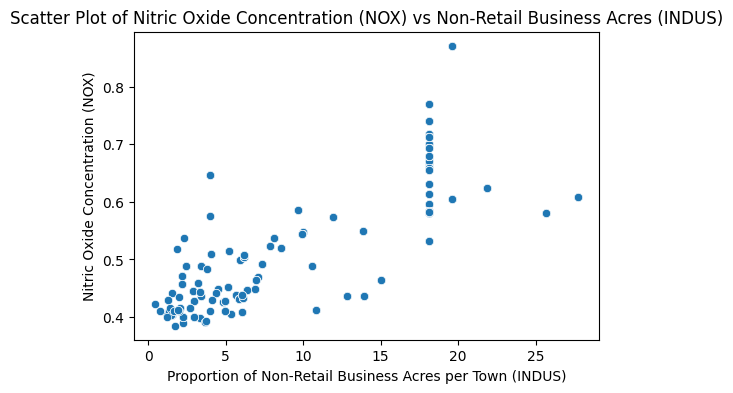

Observation: The scatter plot visualizes the relationship between NOX and INDUS. A pattern here helps determine whether correlation tests are justified.


In [ ]:
# 5. Scatter plot: NOX vs INDUS
plt.figure(figsize=(6,4))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
plt.title("Scatter Plot of Nitric Oxide Concentration (NOX) vs Non-Retail Business Acres (INDUS)")
plt.xlabel("Proportion of Non-Retail Business Acres per Town (INDUS)")
plt.ylabel("Nitric Oxide Concentration (NOX)")
plt.show()

print("Observation: The scatter plot visualizes the relationship between NOX and INDUS. "
      "A pattern here helps determine whether correlation tests are justified.")


#Task 3:
Use the appropriate tests to answer the questions provided.

In [ ]:
#1. T-test: MEDV for houses by CHAS
# Hypotheses:
# H0: No difference in median house value between CHAS=0 and CHAS=1
# H1: There is a difference
#Alpha = 0.05

chas0 = boston_df[boston_df['CHAS']==0]['MEDV']
chas1 = boston_df[boston_df['CHAS']==1]['MEDV']

t_stat, p_value = stats.ttest_ind(chas0, chas1)
print("T-test for MEDV by CHAS:")
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Reject H0 → Significant difference in median house values based on Charles River proximity.\n")
else:
    print("Conclusion: Fail to reject H0 → No significant difference in median house values.\n")


T-test for MEDV by CHAS:
t-statistic = -3.9964, p-value = 0.0001
Conclusion: Reject H0 → Significant difference in median house values based on Charles River proximity.



In [ ]:
# 2. ANOVA: MEDV by AGE groups
# Hypotheses:
# H0: No difference in median house values among AGE groups
# H1: At least one AGE group differs

# Using AGE_group from Task 2
anova_result = stats.f_oneway(
    boston_df[boston_df['AGE_group']=='<=35']['MEDV'],
    boston_df[boston_df['AGE_group']=='36-70']['MEDV'],
    boston_df[boston_df['AGE_group']=='>70']['MEDV']
)
print("ANOVA for MEDV by AGE groups:")
print(f"F-statistic = {anova_result.statistic:.4f}, p-value = {anova_result.pvalue:.4f}")

if anova_result.pvalue < 0.05:
    print("Conclusion: Reject H0 → Median house values differ across AGE groups.\n")
else:
    print("Conclusion: Fail to reject H0 → No significant difference in median house values.\n")


ANOVA for MEDV by AGE groups:
F-statistic = 36.4076, p-value = 0.0000
Conclusion: Reject H0 → Median house values differ across AGE groups.



Pearson Correlation between NOX and INDUS:
Correlation coefficient = 0.7637, p-value = 0.0000
Conclusion: Reject H0 → There is a significant correlation between NOX and INDUS.



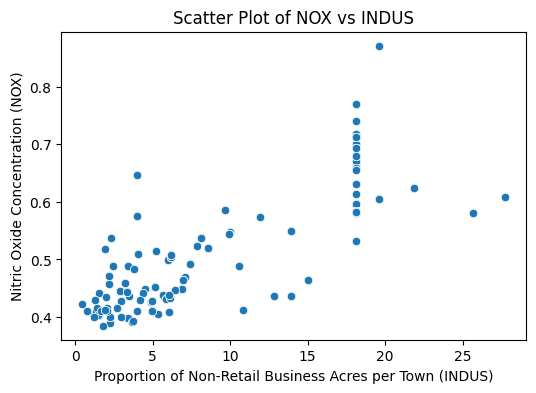

In [ ]:

# 3. Pearson Correlation: NOX vs INDUS
# Hypotheses:
# H0: No correlation between NOX and INDUS
# H1: There is a correlation

corr, p_val_corr = stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])
print("Pearson Correlation between NOX and INDUS:")
print(f"Correlation coefficient = {corr:.4f}, p-value = {p_val_corr:.4f}")

if p_val_corr < 0.05:
    print("Conclusion: Reject H0 → There is a significant correlation between NOX and INDUS.\n")
else:
    print("Conclusion: Fail to reject H0 → No significant correlation.\n")

# Scatter plot for NOX vs INDUS
plt.figure(figsize=(6,4))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df)
plt.title("Scatter Plot of NOX vs INDUS")
plt.xlabel("Proportion of Non-Retail Business Acres per Town (INDUS)")
plt.ylabel("Nitric Oxide Concentration (NOX)")
plt.show()


In [ ]:
#4. Regression: MEDV vs DIS
# ---------------------------------------
# Hypotheses:
# H0: Distance to employment centers has no effect on MEDV
# H1: Distance to employment centers affects MEDV

model = ols('MEDV ~ DIS', data=boston_df).fit()
print(model.summary())

# Interpretation
print("\nConclusion:")
if model.pvalues['DIS'] < 0.05:
    print("Reject H0 → Distance to employment centers has a significant impact on median home value.")
    print(f"Interpretation: For each additional unit of weighted distance to employment centers, "
          f"MEDV changes by {model.params['DIS']:.4f} thousand dollars on average.\n")
else:
    print("Fail to reject H0 → Distance to employment centers has no significant impact on median home value.\n")

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           1.21e-08
Time:                        18:41:44   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.3901      0.817     22.499      0.0

#Perform a predictive machine learning model
## Model 1: Simple Linear Regression
###Simple Regression MEDV~DIS

### Step 1: Prepare the Data

In [45]:
# Step 1a: inspect relevant columns
print(boston_df[['MEDV','DIS']].head())
print(boston_df[['MEDV','DIS']].describe())

   MEDV     DIS
0  24.0  4.0900
1  21.6  4.9671
2  34.7  4.9671
3  33.4  6.0622
4  36.2  6.0622
             MEDV         DIS
count  506.000000  506.000000
mean    22.532806    3.795043
std      9.197104    2.105710
min      5.000000    1.129600
25%     17.025000    2.100175
50%     21.200000    3.207450
75%     25.000000    5.188425
max     50.000000   12.126500


In [46]:
# Step 1b: drop NA if any (safe-guard)
df = boston_df[['MEDV','DIS']].dropna().copy()

In [47]:
# Step 1c: define X and y
X = df[['DIS']].values    # feature matrix (2D)
y = df['MEDV'].values     # target (1D)

### Step 2: Train/Test Split

In [48]:
# Step 2: split (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (354, 1) (354,)
Test shape: (152, 1) (152,)


### Step 3: Scaling features

In [51]:
# Step 3: scaling (useful for multiple features or regularized models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### Step 4: Fit the model (Simple linear regression)

In [52]:
# Step 4: model fitting
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)   # scaled inputs

# Coefficients & intercept
coef = lr.coef_[0]
intercept = lr.intercept_
print(f"Intercept = {intercept:.4f}")
print(f"Coefficient (DIS, scaled) = {coef:.4f}")

Intercept = 23.0158
Coefficient (DIS, scaled) = 2.2625


### Step 5: Predict and evaluate

R^2 on test set: 0.0394
RMSE on test set: 8.4604 (in $1000s)


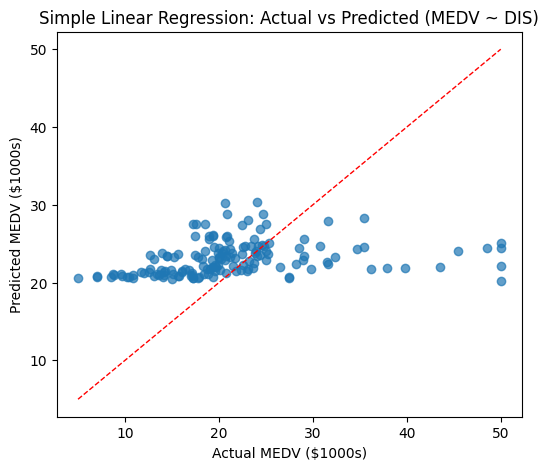

In [55]:
# Step 5: predict
y_pred = lr.predict(X_test_scaled)

# Metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2 on test set: {r2:.4f}")
print(f"RMSE on test set: {rmse:.4f} (in $1000s)")

# Plot actual vs predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.xlabel("Actual MEDV ($1000s)")
plt.ylabel("Predicted MEDV ($1000s)")
plt.title("Simple Linear Regression: Actual vs Predicted (MEDV ~ DIS)")
plt.show()

### Step 6: Residual diagnostic
*residuals should be roughly centered at 0, show no pattern vs predictions (linearity/homoscedasticity), and be approximately normal for inference.*

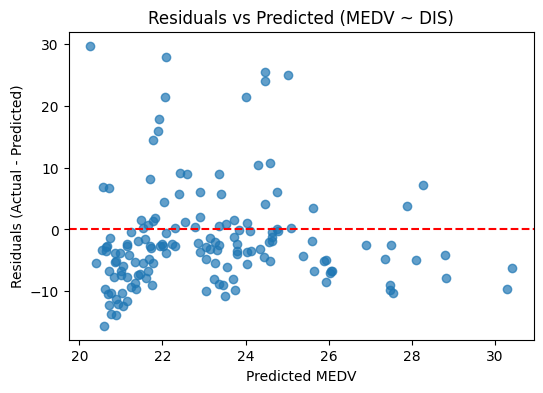

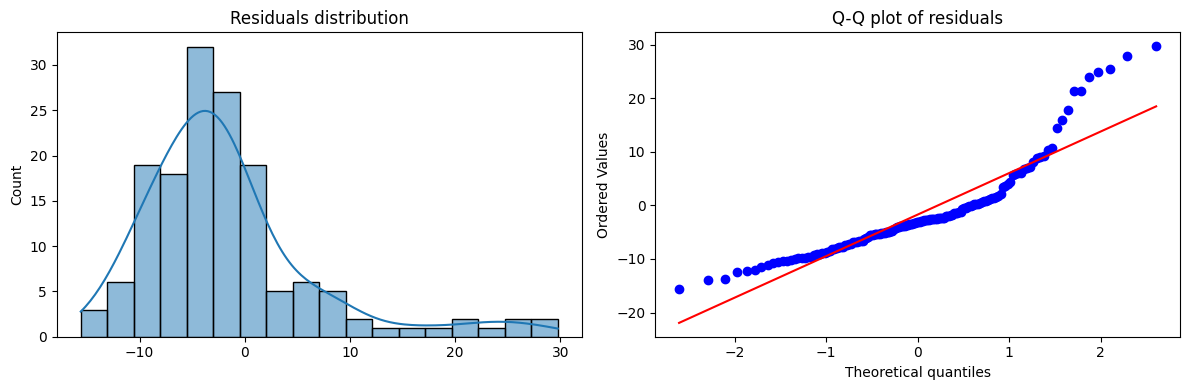

In [56]:
residuals = y_test - y_pred

# Residual plot
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted MEDV")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted (MEDV ~ DIS)")
plt.show()

# Histogram + Q-Q plot for residuals
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")

plt.subplot(1,2,2)
import scipy.stats as stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()

### Step 7: Cross-Validation

In [57]:
# Deploying cross-validation on the whole X,y (scaled)
X_scaled = scaler.fit_transform(X)   # scale full feature for CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(LinearRegression(), X_scaled, y, cv=cv, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(LinearRegression(), X_scaled, y, cv=cv, scoring='neg_mean_squared_error'))

print("CV R^2 scores:", np.round(cv_r2, 4))
print("CV R^2 mean:", np.round(cv_r2.mean(), 4))
print("CV RMSE mean:", np.round(cv_rmse.mean(), 4))

CV R^2 scores: [0.0733 0.0529 0.0651 0.0546 0.0029]
CV R^2 mean: 0.0498
CV RMSE mean: 8.899


#Perform a predictive machine learning model
## Model 2: Multiple Linear Regression (recommended for better performance)
Pick predictors based on domain and correlation with MEDV (e.g., RM, LSTAT, PTRATIO, DIS, NOX, CHAS). If CHAS is categorical, encode it (0/1 is fine).

### Step 1: Data Preparation

In [58]:
# choose features
features = ['RM','LSTAT','PTRATIO','DIS','NOX','CHAS']   # adjust as you like
df_multi = boston_df[features + ['MEDV']].dropna().copy()

# Ensure CHAS is numeric (0/1)
df_multi['CHAS'] = df_multi['CHAS'].astype(int)

# X and y
X = df_multi[features].values
y = df_multi['MEDV'].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


### Step 2: Fit Multiple Linear Regression

In [59]:
# Fit
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Coefs mapped to feature names
coefs = pd.Series(lr.coef_, index=features)
intercept = lr.intercept_

print("Intercept:", intercept)
print("\nCoefficients (per 1 std change in predictor):")
print(coefs.sort_values(ascending=False))


Intercept: 23.01581920903957

Coefficients (per 1 std change in predictor):
RM         2.936269
CHAS       1.031340
NOX       -1.904967
PTRATIO   -2.132710
DIS       -2.223249
LSTAT     -4.255627
dtype: float64


###Step 3: Predict and Evaluate

Test R^2: 0.6934
Test RMSE: 4.7798


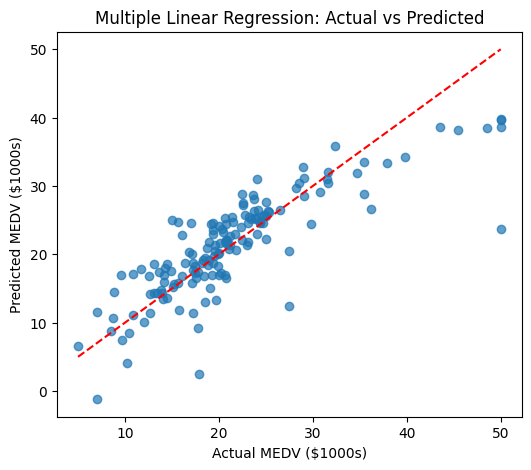

In [60]:
y_pred = lr.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test R^2: {r2:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Scatter plot actual vs predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual MEDV ($1000s)")
plt.ylabel("Predicted MEDV ($1000s)")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()


### Cross Validation and regularization

In [61]:
# 5-fold CV R^2 (multiple features)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(LinearRegression(), scaler.fit_transform(X), y, cv=cv, scoring='r2')
print("CV R^2 mean:", np.round(cv_r2.mean(),4))

# Try Ridge regression with alpha tuning (simple)
from sklearn.model_selection import GridSearchCV
ridge = Ridge()
param_grid = {'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
gs = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
gs.fit(scaler.fit_transform(X), y)
print("Best ridge alpha:", gs.best_params_, "Best CV R^2:", gs.best_score_)


CV R^2 mean: 0.7001
Best ridge alpha: {'alpha': 50.0} Best CV R^2: 0.4665775172500813


### Diagnostic

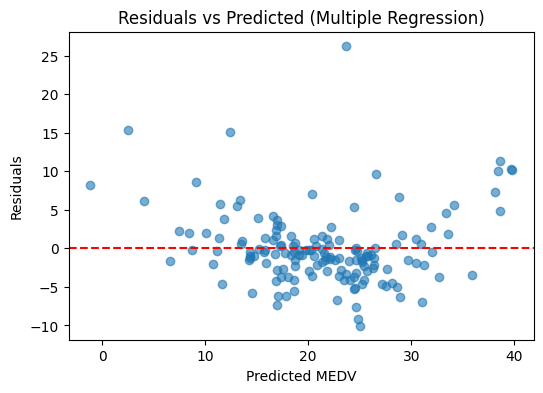

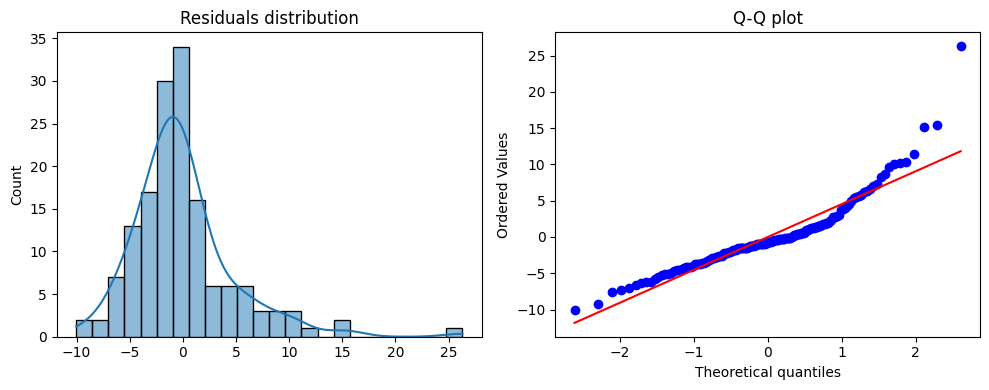

In [62]:
residuals = y_test - y_pred

# Residuals vs predicted
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted MEDV")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Multiple Regression)")
plt.show()

# Q-Q
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")
plt.subplot(1,2,2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q plot")
plt.tight_layout()
plt.show()


#Model Interpretation and Results

Model performance (multiple regression):
The model achieved a test R² of 0.6934, indicating that approximately 69% of the variance in median home value (MEDV) is explained by the selected predictors.
The test RMSE is 4.78 ($1000s), meaning that on average, the model’s predictions deviate from actual values by about $4,780.
Cross-validation confirmed a consistent performance, with a mean CV R² of 0.7001, demonstrating good generalization.
A Ridge regression was also tested for regularization; the best α value was 50, yielding a lower CV R² of 0.4666, suggesting that the simple linear model performed better in this case.

Feature importance (standardized coefficients):

RM (+2.94): Average number of rooms per dwelling has the strongest positive effect on house prices — homes with more rooms tend to be more expensive.

CHAS (+1.03): Proximity to the Charles River positively influences property values, reflecting the desirability of waterfront locations.

NOX (–1.90): Higher nitrogen oxide concentration (air pollution) decreases house prices, indicating environmental quality matters to buyers.

PTRATIO (–2.13): Higher pupil–teacher ratios (indicating poorer school quality) reduce home values.

DIS (–2.22): Greater distance to employment centers slightly decreases home values, reflecting the impact of accessibility.

LSTAT (–4.26): Percentage of lower-status population has the strongest negative effect, confirming its known inverse relationship with housing prices.

Intercept: 23.02 represents the predicted median house value (in $1000s) when all standardized predictors are at their mean (i.e., 0 after scaling).

Diagnostics:
Residual plots showed no major violation of linearity or homoscedasticity assumptions, and residuals were approximately normally distributed.
This supports that a linear model is appropriate for this dataset.

Summary:
Overall, the multiple linear regression model explains a large portion of the variability in Boston housing prices and identifies room count, socioeconomic status, and proximity to pollution or key amenities as the main driving factors.